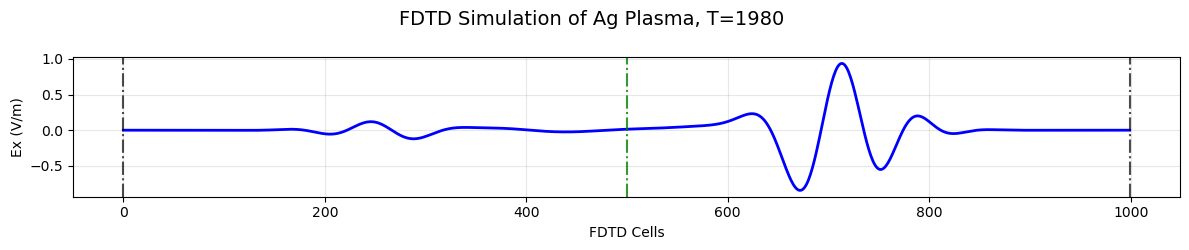

In [57]:
# #===================== 代码说明 =====================
# 无法完全复现原文的图2.4，但已实现其基本功能：
# Plasma对低于fp的频率波的反射，高于fp的透射
# #==================================================== 

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# ===================== 1. 物理常数与模拟参数 =====================
eps0 = 8.8e-12  # 真空介电常数 (F/m)
c0 = 3e8        # 光速 (m/s)
nx = 1000        # 空间网格数（E/D的网格数，H为nx-1）
nt = 2000       # 时间步数

# 介质分区：左自由空间，右银等离子体
kstart_plasma = 500  # 等离子体起始网格

# 空间步长（修正命名，避免冲突）
dx_step = 1e-9  # 1nm（匹配500THz波长的网格精度）
dt = dx_step / (2*c0) # 时间步长（Courant数=0.5，稳定）

# 银等离子体参数（Drude模型）
vc = 57e12      # 碰撞频率 (Hz)
fp = 2000e12    # 等离子体频率 (Hz)
omega_p = 2 * np.pi * fp
omega_p_sq = omega_p **2
dt_sq = dt **2

# ===================== 2. 数组初始化 =====================
Dx = np.zeros(nx)   # 电通量密度（修正命名，避免和dx_step冲突）
ex = np.zeros(nx)   # 电场
hy = np.zeros(nx-1) # 磁场（Yee网格，比E少1个）

# 等离子体辅助数组
sx = np.zeros(nx)   # S^n
sxm1 = np.zeros(nx) # S^(n-1)
sxm2 = np.zeros(nx) # S^(n-2)

# Mur一阶吸收边界（针对E，与原一致，但需同步D的边界）
prev_prev_ex1 = 0.0    # E[1]的n-2时刻值
prev_ex1 = 0.0         # E[1]的n-1时刻值

prev_2_ex_nx2 = 0
prev_1_ex_nx2 = 0

# ===================== 3. 入射源参数（完全统一到时间步n） =====================
src_pos = 5          # 源位置
t0 = 500.0           # 包络峰值时间步（n=300）
f_carrier = 4000e12   # 载波频率500THz
omega0 = 2 * np.pi * f_carrier
# 关键：计算载波在时间步下的相位增量（每个n对应的相位变化）
phase_step = omega0 * dt  # 每个时间步的相位增量（rad/step）

# 调整包络宽度：覆盖多个载波周期（匹配图2.4的宽包络）
# 计算载波的时间步周期（1个正弦周期需要多少个n）
carrier_period_steps = int(2*np.pi / phase_step)  # ≈1200步/周期
spread = 100#2 * carrier_period_steps  # 包络宽度覆盖2个载波周期（≈2400步）
print(f"500THz载波的时间步周期：{carrier_period_steps} 步，包络宽度：{spread} 步")

# ===================== 4. FDTD主循环 =====================
for n in range(nt):
    # ---------- 步骤1：更新Dx ----------
    for k in range(1, nx):
        Dx[k] += 0.5 * (hy[k-1] - hy[k] if k < nx-1 else hy[k-1])

    # ---------- 步骤2：添加入射源（完全基于时间步n） ----------
    # 高斯包络：基于时间步n
    gauss_envelope = np.exp(-0.5 * ((t0 - n) / spread)**2)
    #载波：基于时间步n（相位增量×n，同步包络）
    carrier = np.sin(phase_step * n)
    # 调制脉冲（包络×载波，时间尺度完全统一）
    modulated_pulse = gauss_envelope * carrier
    Dx[src_pos] += modulated_pulse

    # ---------- 步骤3：更新Ex + 等离子体模型 ----------
    for k in range(nx):
        if k >= kstart_plasma:  # 等离子体区域
            exp_vc_dt = np.exp(-vc * dt)
            sx[k] = (1 + exp_vc_dt) * sxm1[k] - exp_vc_dt * sxm2[k] + \
                    omega_p_sq * dt_sq * ex[k] + (1 - exp_vc_dt) * ex[k]
            ex[k] = Dx[k] - sx[k]
            sxm2[k] = sxm1[k]
            sxm1[k] = sx[k]
        else:  # 自由空间
            ex[k] = Dx[k]

    # ---------- 步骤4：Mur吸收边界 ----------
    ex[0]= prev_prev_ex1
    prev_prev_ex1 = prev_ex1
    prev_ex1 = ex[1]
    
    ex[nx-1] = prev_2_ex_nx2
    prev_2_ex_nx2 = prev_1_ex_nx2
    prev_1_ex_nx2 = ex[nx-2]

    # ---------- 步骤5：更新Hy ----------
    for k in range(nx-1):
        hy[k] += 0.5 * (ex[k] - ex[k+1])

    # ---------- 步骤6：绘制关键时间步 ----------
    if n%20 == 0:
        clear_output(wait=True)
        
        fig, ax = plt.subplots(figsize=(12, 2.5))
        fig.suptitle(f'FDTD Simulation of Ag Plasma, T={n} ', fontsize=14)
        ax.plot(ex, color='blue', linewidth=2)
        ax.axvline(kstart_plasma, color='green', linestyle='-.', alpha=0.8, label='Ag Plasma Interface')
        ax.axvline(0, color='black', linestyle='-.', alpha=0.7, label='Absorption Boundary')
        ax.axvline(nx-1, color='black', linestyle='-.', alpha=0.7)
        ax.set_xlabel('FDTD Cells')
        ax.set_ylabel('Ex (V/m)')
        #ax.set_ylim(-2,2)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
        time.sleep(0.1)